<a href="https://colab.research.google.com/github/zhuhanzhi6/Hanzhi-Zhu-machine-learning/blob/main/Lecture9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Research Challenge

<div style="background-color: #f8d7da; border-left: 6px solid #ccc; margin: 20px; padding: 15px;">
    <strong>💡 Margaret Atwood:</strong> Every aspect of human technology has a dark side, including the bow and arrow.
</div>

## 🏅 Build your own model

It is time to go back to supervised machine learning problems.

You have been assigned one dataset from [MatBench](https://matbench.materialsproject.org) as introduced in the [Lecture slides](https://speakerdeck.com/aronwalsh/mlformaterials-challenge-25). You are free to choose and tune any machine-learning model, with any Python library, but it should be appropriate for the problem. For instance, [XGBoost](https://xgboost.readthedocs.io) could be a good starting starting point to build a regression model. You can refer back to earlier notebooks and repurpose code as needed.

You may reach the limits of computing processing power on Google Colab. Building a useful model with limited resources is a real-world skill. Using other free resources is allowed if you find an alternative service, as is running on your own computer. A model tracker such as [wandb](https://wandb.ai) could be helpful for advanced users. If you want to try a brute force approach, a library such as [Automatminer](https://hackingmaterials.lbl.gov/automatminer) may be of interest.

This notebook should be used for keeping a record of your model development, submission, and even your presentation. You are free to edit (add/remove/delete) or rearrange the cells as you see fit.

### Your details

In [17]:
import numpy as np

# Insert your values
Name = "Hanzhi Zhu" # Replace with your name
CID = 2243276 # Replace with your College ID (as a numeric value with no leading 0s)

# Set a random seed using the CID value
CID = int(CID)
np.random.seed(CID)

# Print the message
print("This is the work of " + Name + " [CID: " + str(CID) + "]\n")

# Define the available groups
groups = ['A', 'B', 'C', 'D', 'E']

# Select a group based on the seeded random state
challenge_group = np.random.choice(groups)

# Print the challenge code
print("Your challenge code is " + challenge_group)

This is the work of Hanzhi Zhu [CID: 2243276]

Your challenge code is B


## Problem statement

You have been assigned one dataset from the [list](https://matbench.materialsproject.org/Benchmark%20Info/matbench_v0.1/) on [MatBench](https://matbench.materialsproject.org). You should state what problem you are trying to solve and comment on the best-performing model in the benchmark.

Matbench v0.1 test dataset for predicting experimental band gap from composition alone.
Retrieved from Zhuo et al. supplementary information.
Deduplicated according to composition, removing compositions with reported band gaps spanning more than a 0.1eV range;
remaining compositions were assigned values based on the closest experimental value to the mean experimental value for that composition among all reports.
For benchmarking with nested cross validation, the order of the dataset must be identical to the retrieved data; refer to the Automatminer/Matbench publication for more details.




## Data preparation

Check the data distribution and apply appropriate pre-processing steps as required.

In [18]:
# Installation of libraries
!pip install matminer==0.9.3 xgboost==2.1.0 scikit-learn==1.3.2


In [19]:
# Get dataset info from matminer
from matminer.datasets import get_all_dataset_info
from matminer.datasets import load_dataset

# Detailed on https://hackingmaterials.lbl.gov/matminer/dataset_summary.html
# Uncomment the info line for your assigned challenge code

  # A
#info = get_all_dataset_info("matbench_dielectric")

  # B
info = get_all_dataset_info("matbench_expt_gap")

  # C
#info = get_all_dataset_info("matbench_expt_is_metal")

  # D
#info = get_all_dataset_info("matbench_glass")

  # E
#info = get_all_dataset_info("matbench_steels")

# Check the dataset information
print(info)

Dataset: matbench_expt_gap
Description: Matbench v0.1 test dataset for predicting experimental band gap from composition alone. Retrieved from Zhuo et al. supplementary information. Deduplicated according to composition, removing compositions with reported band gaps spanning more than a 0.1eV range; remaining compositions were assigned values based on the closest experimental value to the mean experimental value for that composition among all reports. For benchmarking w/ nested cross validation, the order of the dataset must be identical to the retrieved data; refer to the Automatminer/Matbench publication for more details.
Columns:
	composition: Chemical formula.
	gap expt: Target variable. Experimentally measured gap, in eV.
Num Entries: 4604
Reference: Y. Zhuo, A. Masouri Tehrani, J. Brgoch (2018) Predicting the Band Gaps of Inorganic Solids by Machine Learning J. Phys. Chem. Lett. 2018, 9, 7, 1668-1673 https:doi.org/10.1021/acs.jpclett.8b00124.
Bibtex citations: ["@Article{Dunn2020

The MatBench experimental band gap dataset (matbench_expt_gap) was first loaded, containing chemical compositions together with their experimentally measured band gaps. Basic checks, including dataset size, sample inspection and descriptive statistics, were carried out to verify correct data loading. The distribution of band gap values was then visualised using a histogram, and the proportion of zero-gap entries was calculated to assess the prevalence of metallic or near-metallic compounds, which can influence model bias and prediction difficulty.

Chemical compositions were subsequently converted into numerical descriptors using the Magpie composition featuriser from matminer. This approach transforms chemical formulae into statistically derived elemental-property features that are suitable for machine learning models. Following featurisation, missing data were assessed: features with more than 30% missing values were removed to avoid unreliable predictors, while remaining missing values were imputed using feature means to maintain dataset completeness.

Dataset shape: (4604, 2)
         composition  gap expt
0           Ag(AuS)2      0.00
1         Ag(W3Br7)2      0.00
2   Ag0.5Ge1Pb1.75S4      1.83
3  Ag0.5Ge1Pb1.75Se4      1.51
4             Ag2BBr      0.00

Summary statistics:
count    4604.000000
mean        0.975951
std         1.445034
min         0.000000
25%         0.000000
50%         0.000000
75%         1.812500
max        11.700000
Name: gap expt, dtype: float64


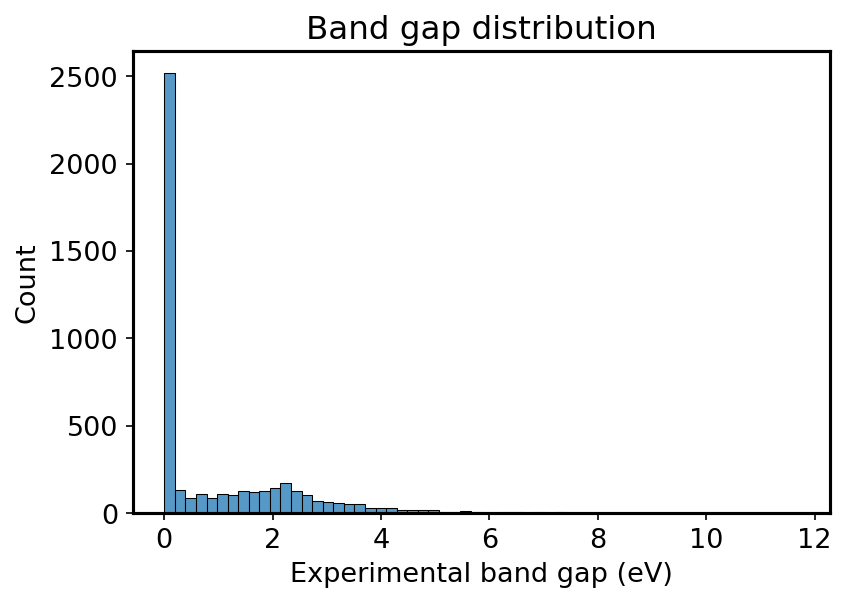

Fraction metallic (Eg=0): 0.532


/usr/local/lib/python3.12/dist-packages/matminer/utils/data.py:326: UserWarning: MagpieData(impute_nan=False):
In a future release, impute_nan will be set to True by default.
                    This means that features that are missing or are NaNs for elements
                    from the data source will be replaced by the average of that value
                    over the available elements.
                    This avoids NaNs after featurization that are often replaced by
                    dataset-dependent averages.
  warnings.warn(f"{self.__class__.__name__}(impute_nan=False):\n" + IMPUTE_NAN_WARNING)


ElementProperty:   0%|          | 0/4604 [00:00<?, ?it/s]

Feature matrix shape: (4604, 135)
After variance filtering: (4604, 132)
After correlation filtering: (4604, 114)
Train: (3683, 114)
Test: (921, 114)

Data preparation complete.


In [20]:

# DATA PREPARATION


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matminer.datasets import load_dataset
from pymatgen.core import Composition
from matminer.featurizers.composition.composite import ElementProperty

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

np.random.seed(42)

# Load dataset

df_raw = load_dataset("matbench_expt_gap")

print("Dataset shape:", df_raw.shape)
print(df_raw.head())


# Basic data exploration

print("\nSummary statistics:")
print(df_raw["gap expt"].describe())

plt.figure(figsize=(6,4))
sns.histplot(df_raw["gap expt"], bins=60)
plt.xlabel("Experimental band gap (eV)")
plt.title("Band gap distribution")
plt.show()

# Metallic fraction (gap=0)
zero_fraction = (df_raw["gap expt"] == 0).mean()
print(f"Fraction metallic (Eg=0): {zero_fraction:.3f}")


# Composition featurisation

df = df_raw.copy()

df["composition_obj"] = df["composition"].apply(Composition)

featuriser = ElementProperty.from_preset("magpie")
featuriser.set_n_jobs(1)

df = featuriser.featurize_dataframe(
    df,
    col_id="composition_obj",
    ignore_errors=True
)

print("Feature matrix shape:", df.shape)


# Handle missing values

missing_frac = df.isna().mean().sort_values(ascending=False)

# Drop features with >30% missing values
drop_cols = missing_frac[missing_frac > 0.3].index
df.drop(columns=drop_cols, inplace=True)

# Fill remaining NaNs with column mean
df.fillna(df.mean(numeric_only=True), inplace=True)


# Remove low-variance features (helps prevent noise / overfitting)


X = df.drop(columns=["composition", "gap expt", "composition_obj"])
y = df["gap expt"].values

selector = VarianceThreshold(threshold=1e-5)
X = pd.DataFrame(
    selector.fit_transform(X),
    columns=X.columns[selector.get_support()]
)

print("After variance filtering:", X.shape)


# Remove highly correlated features


corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
X.drop(columns=to_drop, inplace=True)

print("After correlation filtering:", X.shape)


# Feature scaling: improves stability for comparisons


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Split the train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


# Final dataset ready for modelling

print("\nData preparation complete.")


To enhance model stability and reduce redundancy, feature filtering was performed in two steps. Low-variance features were removed as they contribute little useful information and may introduce noise, while highly correlated features (correlation coefficient greater than 0.95) were excluded to mitigate multicollinearity. The retained features were then standardised to a common scale, which improves numerical stability and enables fair comparison between different machine learning models. Finally, the processed dataset was split into training and testing subsets using an 80/20 ratio, allowing subsequent model training, cross-validation and unbiased evaluation on unseen data.

Choose relevant features, which may be based on composition or structure, depending on your problem. [matminer](https://hackingmaterials.lbl.gov/matminer/) is a good place to start.

## Model selection, testing and training

Define your model and justify your choice based on the problem and available data. You can look back at earlier notebooks and investigate other examples online including in [scikit-learn](https://scikit-learn.org).

A baseline model using a dummy regressor was first included to provide a reference level of performance based on predicting the mean band gap. Several tree-based regression models, including Random Forest, Gradient Boosting, and XGBoost, were then selected due to their ability to capture nonlinear relationships and their strong performance in materials informatics tasks. These ensemble methods are particularly suitable for composition-based descriptors, where complex interactions between elemental properties often influence material behaviour.

Artificial neural networks were not explored in this study
because the dataset size is relatively small for deep
learning approaches.


Train, validate and test your model. Make sure to do proper data splits and to consider the hyperparamaters of your model.

<details>
<summary>Note on the ROC-AUC classification metric</summary>
There is one metric we didn't cover but is used in Matbench. In binary classification models, the ROC-AUC (Receiver Operating Characteristic - Area Under the Curve) score can be used to evaluate performance. It quantifies the ability of the model to distinguish between positive and negative instances across different decision thresholds. A higher ROC-AUC score (ranging from 0.5 to 1) indicates better performance, with 1 representing a perfect classifier and 0.5 indicating performance no better than random chance. There is a more detailed discussion here: https://developers.google.com/machine-learning/crash-course/classification/roc-and-auc.

The metric can be calculated using the `roc_auc_score` function from the `sklearn.metrics` module, e.g.

```python
from sklearn.metrics import roc_auc_score

# Assuming you have true labels (y_true) and predicted probabilities (y_pred_prob)
y_true = [...]  
y_pred_prob = [...]  

# Calculate ROC-AUC
roc_auc = roc_auc_score(y_true, y_pred_prob)

# Display the result
print(f'ROC-AUC Score: {roc_auc:.4f}')
```
</details>

In [21]:
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb


#Define models
models = {
    "Dummy (mean)": DummyRegressor(strategy="mean"),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        random_state=42
    ),

    "XGBoost": xgb.XGBRegressor(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        objective="reg:squarederror"
    ),
}



Hyperparameter tuning was performed using grid search
with cross-validation on the training set. The optimised
models were then evaluated using cross-validation and a
held-out test set to assess generalisation performance.
Hyperparameter tuning systematically evaluates combinations of key parameters, such as tree depth, number of estimators, and learning rate, to identify configurations that optimise predictive performance. Although only modest improvements were observed after cross validation, tuning ensures that model comparisons reflect intrinsic model capability rather than arbitrary parameter choices.


In [22]:
# Hyperparameter tuning for selected models

from sklearn.model_selection import GridSearchCV



# Random Forest tuning

rf_param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [None, 10, 20]
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best RF params:", rf_grid.best_params_)

models["Random Forest tuned"] = rf_grid.best_estimator_



# Gradient Boosting tuning


gb_param_grid = {
    "n_estimators": [200, 300],
    "learning_rate": [0.03, 0.05, 0.1],
    "max_depth": [2, 3]
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best GB params:", gb_grid.best_params_)

models["Gradient Boosting tuned"] = gb_grid.best_estimator_


# XGBoost tuning


xgb_param_grid = {
    "max_depth": [3, 4, 6],
    "learning_rate": [0.03, 0.05, 0.1],
    "n_estimators": [300, 500]
}

xgb_grid = GridSearchCV(
    xgb.XGBRegressor(objective="reg:squarederror", random_state=42),
    xgb_param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best XGB params:", xgb_grid.best_params_)

models["XGBoost tuned"] = xgb_grid.best_estimator_


Best RF params: {'max_depth': None, 'n_estimators': 300}
Best GB params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300}
Best XGB params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 500}


Model performance was evaluated using 5-fold cross-validation on the training dataset. Root mean squared error (RMSE) and mean absolute error (MAE) were calculated to assess predictive accuracy and robustness. Cross-validation helps reduce sensitivity to a single train–test split by averaging performance across multiple folds, providing a more reliable estimate of model generalisation capability.

In [23]:
# 5-fold CV
def cv_report(model, Xtr, ytr, cv=5):
    rmse_scores = np.sqrt(
        -cross_val_score(model, Xtr, ytr, cv=cv,
                         scoring="neg_mean_squared_error")
    )

    mae_scores = -cross_val_score(
        model, Xtr, ytr, cv=cv,
        scoring="neg_mean_absolute_error"
    )

    return rmse_scores.mean(), rmse_scores.std(), mae_scores.mean(), mae_scores.std()


print("===== CV Results =====")

cv_results = []
for name, model in models.items():
    rmse_m, rmse_s, mae_m, mae_s = cv_report(model, X_train, y_train)

    print(f"{name:18s} | RMSE {rmse_m:.3f} ± {rmse_s:.3f}")

    cv_results.append([name, rmse_m, rmse_s, mae_m, mae_s])

cv_df = pd.DataFrame(
    cv_results,
    columns=["model","cv_rmse_mean","cv_rmse_std","cv_mae_mean","cv_mae_std"]
).sort_values("cv_rmse_mean")

print(cv_df)

# Statistical ranking of model, helps interpret performance differences

best_model = cv_df.iloc[0]["model"]
print(f"\nBest model based on CV RMSE: {best_model}")


===== CV Results =====
Dummy (mean)       | RMSE 1.439 ± 0.036
Random Forest      | RMSE 0.837 ± 0.037
Gradient Boosting  | RMSE 0.845 ± 0.026
XGBoost            | RMSE 0.819 ± 0.032
Random Forest tuned | RMSE 0.837 ± 0.037
Gradient Boosting tuned | RMSE 0.845 ± 0.026
XGBoost tuned      | RMSE 0.819 ± 0.039
                     model  cv_rmse_mean  cv_rmse_std  cv_mae_mean  cv_mae_std
3                  XGBoost      0.819217     0.032094     0.467763    0.009022
6            XGBoost tuned      0.819484     0.039431     0.445264    0.014024
1            Random Forest      0.836523     0.036574     0.463979    0.016232
4      Random Forest tuned      0.836523     0.036574     0.463979    0.016232
2        Gradient Boosting      0.844767     0.026167     0.499929    0.009485
5  Gradient Boosting tuned      0.844767     0.026167     0.499929    0.009485
0             Dummy (mean)      1.439217     0.035505     1.136172    0.022453

Best model based on CV RMSE: XGBoost


Model performance was ranked based on cross-validation RMSE. The XGBoost model showed the lowest validation error, indicating superior predictive capability among the tested models. The inclusion of both baseline and ensemble methods provides context for interpreting performance gains and confirms the advantage of nonlinear ensemble approaches for band gap prediction.

A learning curve analysis was conducted using the best-performing model to evaluate how prediction accuracy varies with training set size. The training error increased gradually with larger datasets, while the cross-validation error decreased and stabilised around ~0.8 eV. This behaviour suggests moderate model variance without severe overfitting. The persistent gap between training and validation errors indicates that predictive performance is likely constrained by data quantity and descriptor information rather than model complexity alone. Further improvements may therefore benefit from larger or more informative datasets.

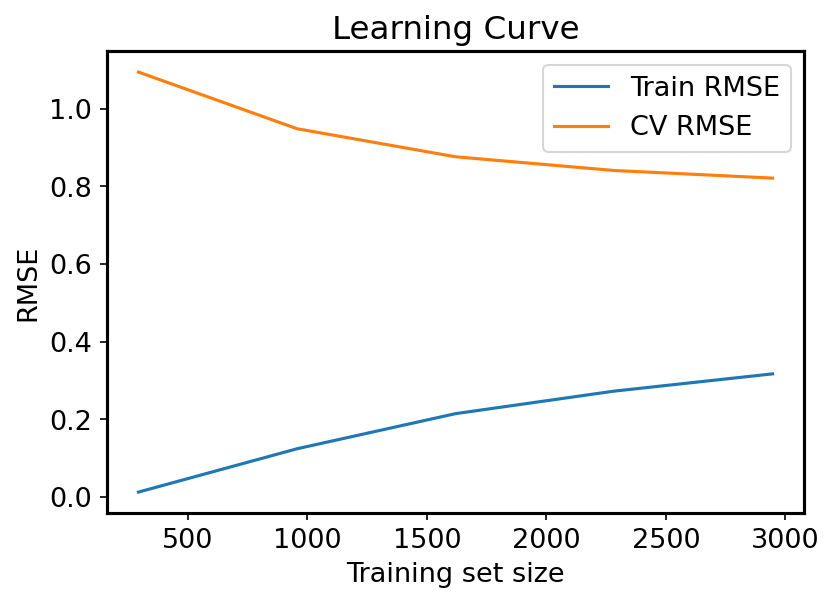

In [24]:
# Learning curve
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

best_model_name = cv_df.iloc[0]["model"]
best_model = models[best_model_name]

train_sizes, train_scores, test_scores = learning_curve(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_rmse = np.sqrt(-train_scores.mean(axis=1))
test_rmse = np.sqrt(-test_scores.mean(axis=1))

plt.figure(figsize=(6,4))
plt.plot(train_sizes, train_rmse, label="Train RMSE")
plt.plot(train_sizes, test_rmse, label="CV RMSE")
plt.xlabel("Training set size")
plt.ylabel("RMSE")
plt.title("Learning Curve")
plt.legend()
plt.show()


## Model analysis and discussion

How well does your final model perform? Think of metrics and plots that are useful to dig a little deeper.

Compare against the best-performing model on the [MatBench](https://matbench.materialsproject.org) leaderboard.  With limited resources, don't expect to match this performance, but you should do better than a baseline model.

The test set results show that the ensemble models perform substantially better than the baseline dummy regressor. The dummy model, which simply predicts the mean band gap, gives an RMSE of about 1.47 eV and essentially zero explanatory power (R² ≈ 0). In contrast, all tree-based models achieve much lower prediction errors. Among them, the tuned XGBoost model provides the best performance with a test RMSE of approximately 0.77 eV, MAE of about 0.42 eV, and R² around 0.72, indicating a strong improvement in predictive accuracy.
All the results were shwon in the bar chart in the next cell.

In [25]:
# Test set evaluation
def evaluate_on_test(model):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae  = mean_absolute_error(y_test, pred)
    r2   = r2_score(y_test, pred)

    return pred, rmse, mae, r2


test_results = []
pred_store = {}

for name, model in models.items():
    pred, rmse, mae, r2 = evaluate_on_test(model)

    pred_store[name] = pred
    test_results.append([name, rmse, mae, r2])

    print(f"{name:18s} | RMSE {rmse:.3f} | MAE {mae:.3f} | R2 {r2:.3f}")

test_df = pd.DataFrame(
    test_results,
    columns=["model","test_rmse","test_mae","test_r2"]
).sort_values("test_rmse")

print(test_df)


Dummy (mean)       | RMSE 1.467 | MAE 1.173 | R2 -0.000
Random Forest      | RMSE 0.837 | MAE 0.444 | R2 0.674
Gradient Boosting  | RMSE 0.851 | MAE 0.495 | R2 0.663
XGBoost            | RMSE 0.779 | MAE 0.443 | R2 0.718
Random Forest tuned | RMSE 0.837 | MAE 0.444 | R2 0.674
Gradient Boosting tuned | RMSE 0.851 | MAE 0.495 | R2 0.663
XGBoost tuned      | RMSE 0.774 | MAE 0.418 | R2 0.722
                     model  test_rmse  test_mae   test_r2
6            XGBoost tuned   0.773638  0.418156  0.721717
3                  XGBoost   0.779327  0.443418  0.717610
1            Random Forest   0.836764  0.443888  0.674451
4      Random Forest tuned   0.836764  0.443888  0.674451
2        Gradient Boosting   0.851224  0.494589  0.663102
5  Gradient Boosting tuned   0.851224  0.494589  0.663102
0             Dummy (mean)   1.466547  1.173240 -0.000006


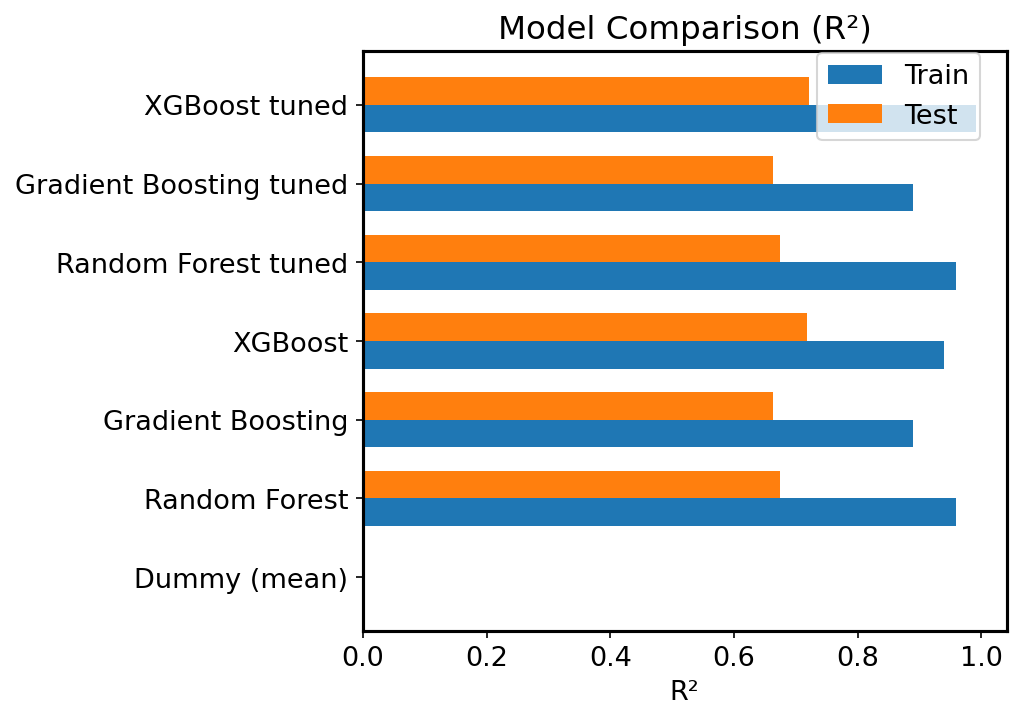

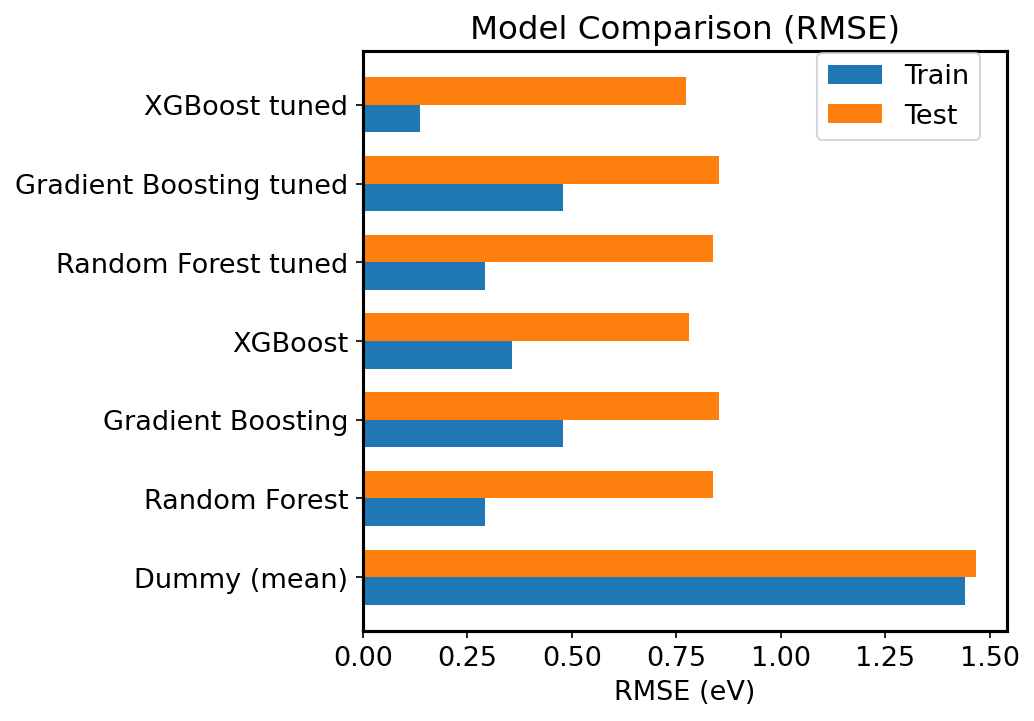

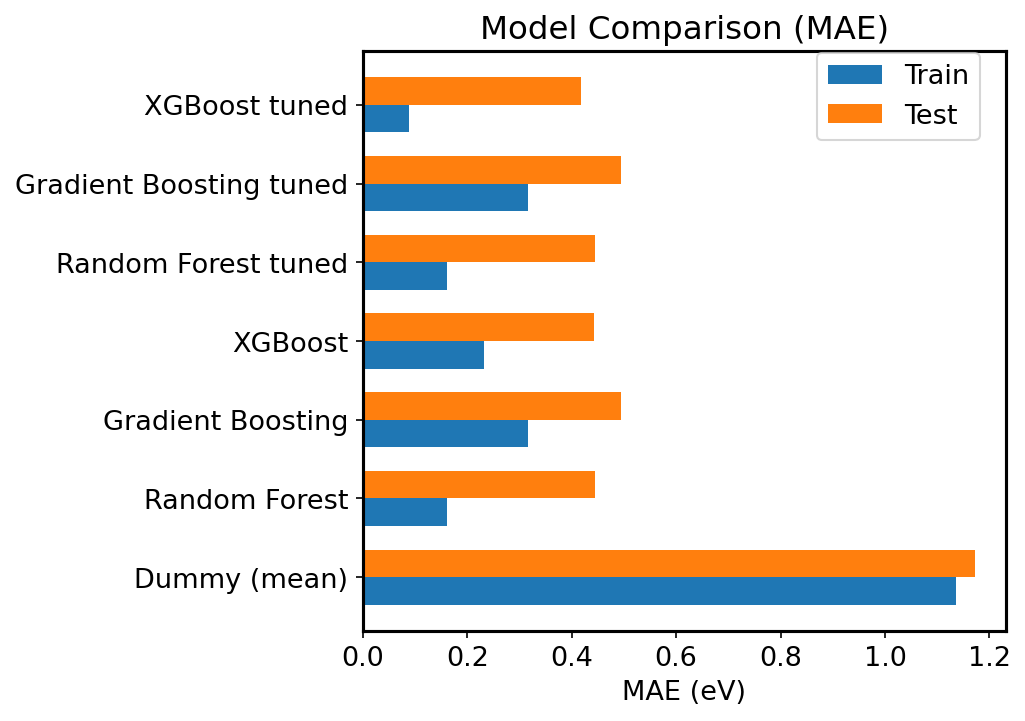

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_test  = model.predict(X_test)

    # metrics
    r2_train = r2_score(y_train, pred_train)
    r2_test  = r2_score(y_test, pred_test)

    rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
    rmse_test  = np.sqrt(mean_squared_error(y_test, pred_test))

    mae_train = mean_absolute_error(y_train, pred_train)
    mae_test  = mean_absolute_error(y_test, pred_test)

    results.append([
        name,
        r2_train, r2_test,
        rmse_train, rmse_test,
        mae_train, mae_test
    ])

df_plot = pd.DataFrame(results, columns=[
    "model",
    "r2_train","r2_test",
    "rmse_train","rmse_test",
    "mae_train","mae_test"
])

def plot_metric(train, test, title, xlabel):
    x = np.arange(len(df_plot["model"]))
    width = 0.35

    plt.figure(figsize=(7,5))

    plt.barh(x - width/2, train, width, label="Train")
    plt.barh(x + width/2, test, width, label="Test")

    plt.yticks(x, df_plot["model"])
    plt.xlabel(xlabel)
    plt.title(title)

    plt.legend(
        loc="upper right",
        bbox_to_anchor=(0.98, 1.02)
    )

    plt.tight_layout()
    plt.show()



plot_metric(df_plot["r2_train"], df_plot["r2_test"],
            "Model Comparison (R²)", "R²")

plot_metric(df_plot["rmse_train"], df_plot["rmse_test"],
            "Model Comparison (RMSE)", "RMSE (eV)")

plot_metric(df_plot["mae_train"], df_plot["mae_test"],
            "Model Comparison (MAE)", "MAE (eV)")


The parity plots compare predicted and true band gap values for each model. The train and test R² values are reported in each plot. It is noted that the tree-based models show a clear correlation between predicted and true values, while the dummy model does not capture this relationship. Among them, XGBoost gives the highest test R², indicating better predictive performance.

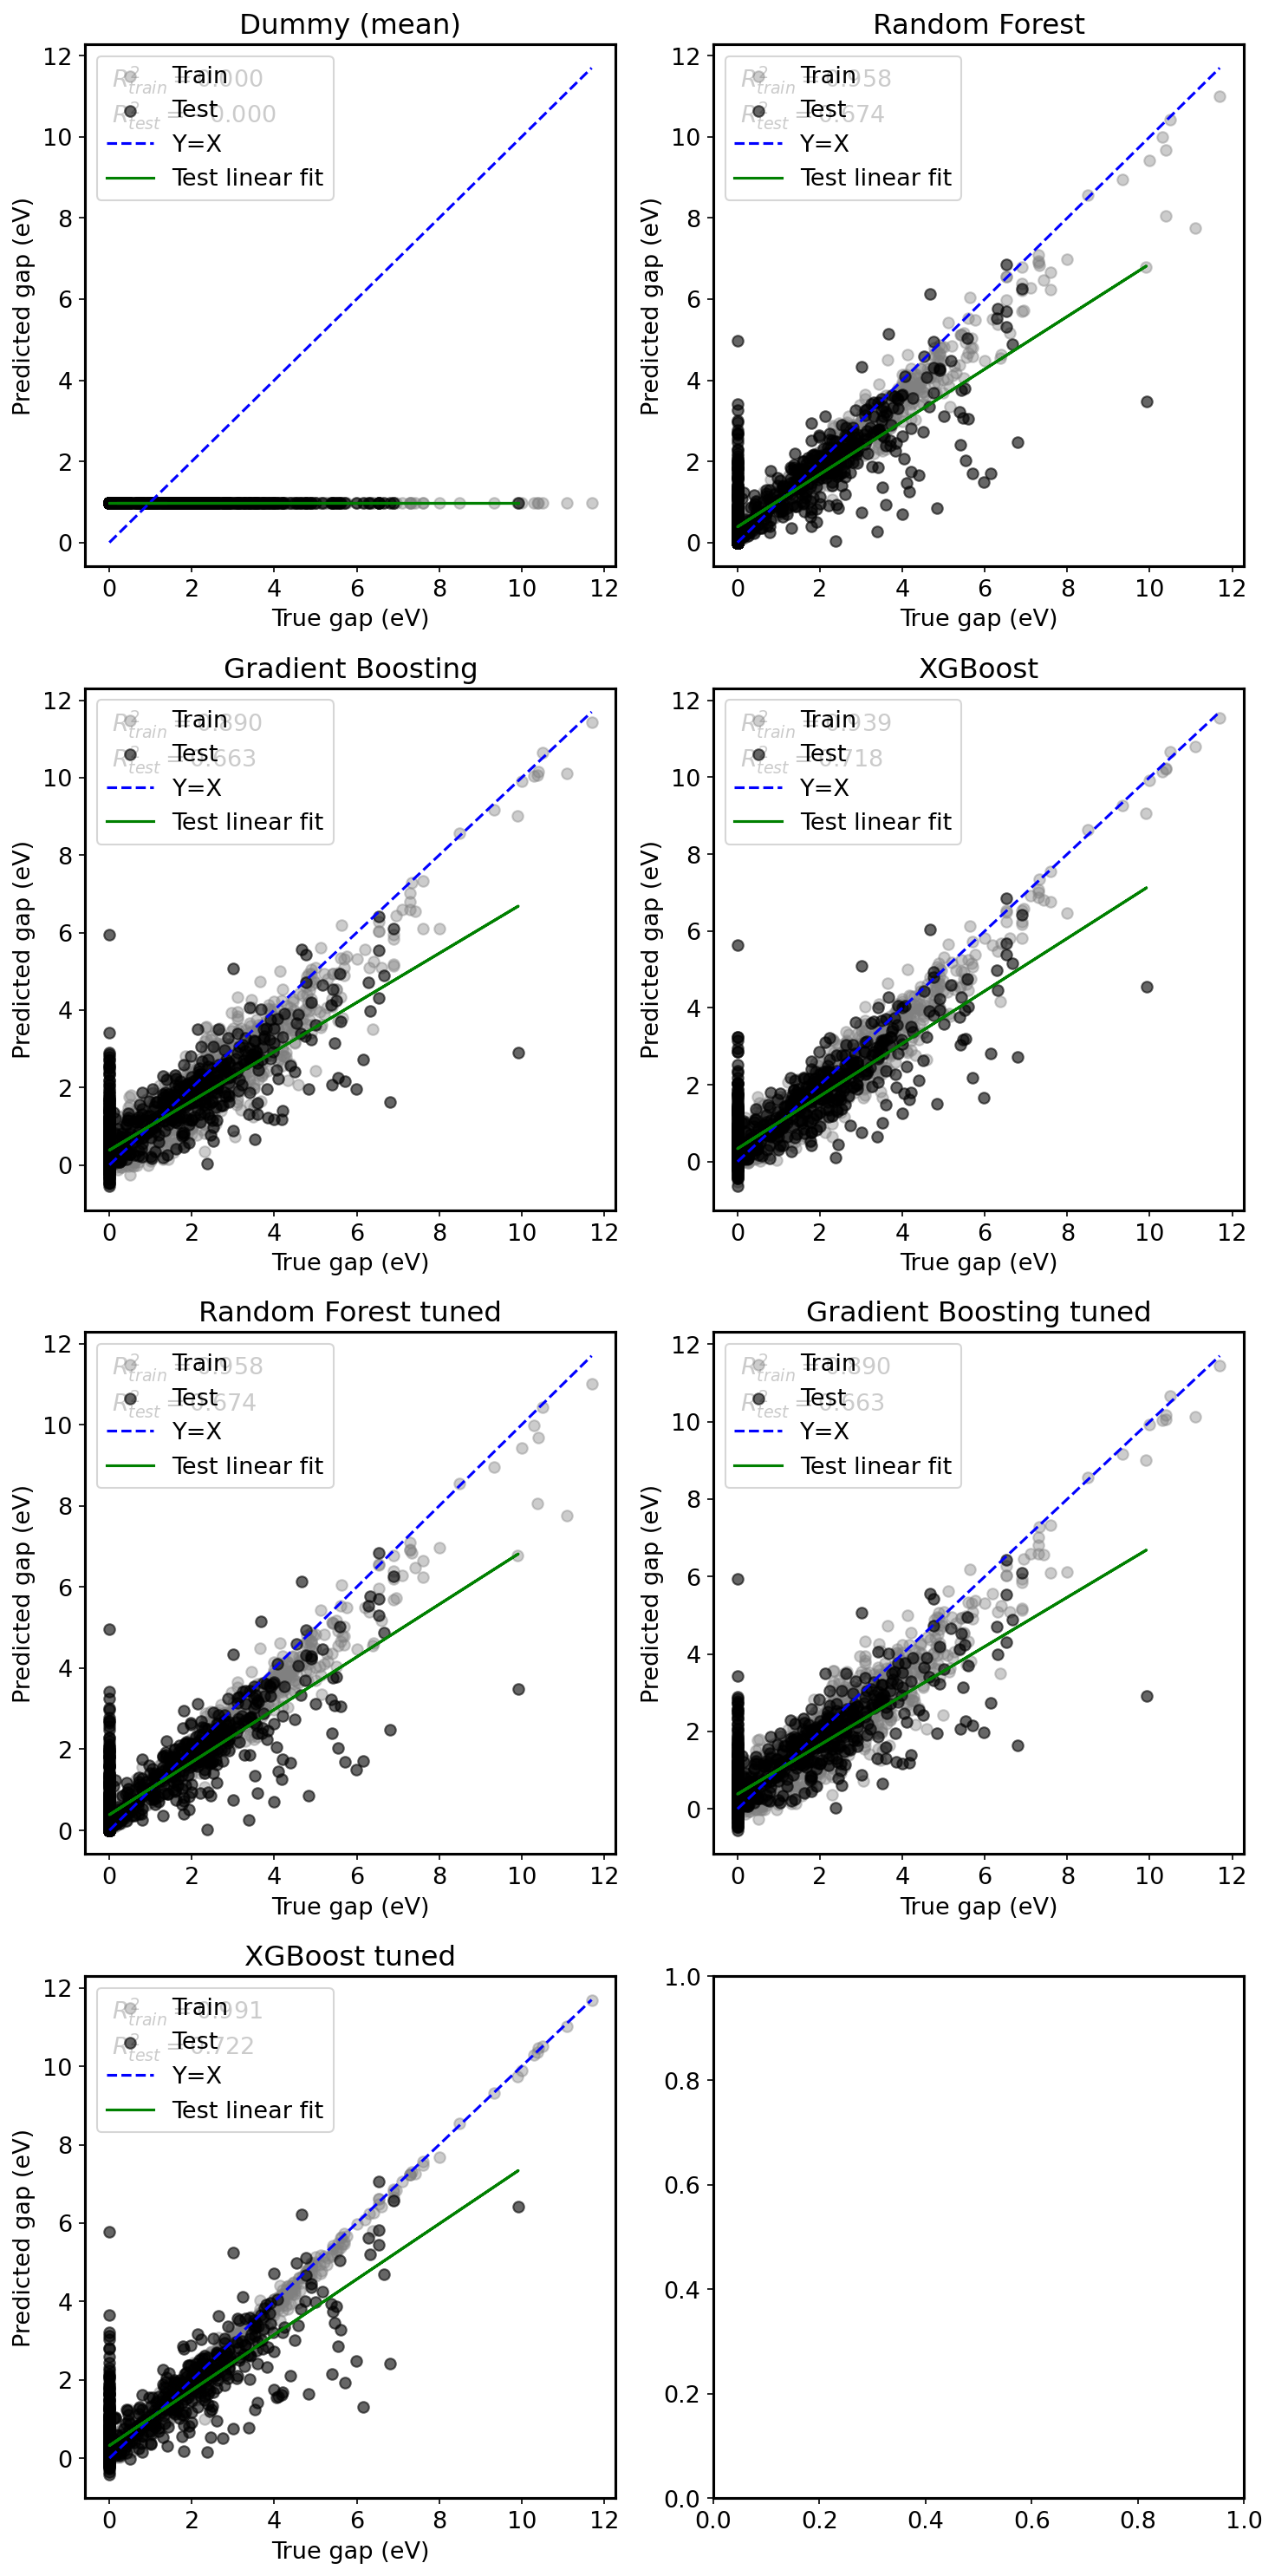

In [27]:
# Multi-model parity plots (ALL models)

n_models = len(models)
cols = 2
rows = int(np.ceil(n_models / cols))

fig, axes = plt.subplots(rows, cols, figsize=(10, 5*rows))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):

    # Train prediction
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)

    # Test prediction
    y_test_pred = model.predict(X_test)

    # Scatter
    ax.scatter(y_train, y_train_pred, color='gray', alpha=0.4, label="Train")
    ax.scatter(y_test, y_test_pred, color='black', alpha=0.6, label="Test")

    # Ideal line
    lims = [0, max(y.max(), y_test_pred.max())]
    ax.plot(lims, lims, 'b--', label="Y=X")

    # Linear fit (test)
    coef = np.polyfit(y_test, y_test_pred, 1)
    fit = np.poly1d(coef)
    ax.plot(y_test, fit(y_test), 'g-', label="Test linear fit")

    # R2
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    ax.text(
        0.05, 0.85,
        f"$R^2_{{train}}={r2_train:.3f}$\n$R^2_{{test}}={r2_test:.3f}$",
        transform=ax.transAxes
    )

    ax.set_title(name)
    ax.set_xlabel("True gap (eV)")
    ax.set_ylabel("Predicted gap (eV)")
    ax.legend()

plt.tight_layout()
plt.show()


Residual analysis shows that prediction errors are
generally centred around zero, indicating no strong
systematic bias in the model. However, the residual
spread increases for larger band gap values, suggesting
reduced predictive accuracy for wide-gap materials.
This behaviour is consistent with composition-based
descriptors, which may lack sufficient structural
information to accurately capture large band gap systems.


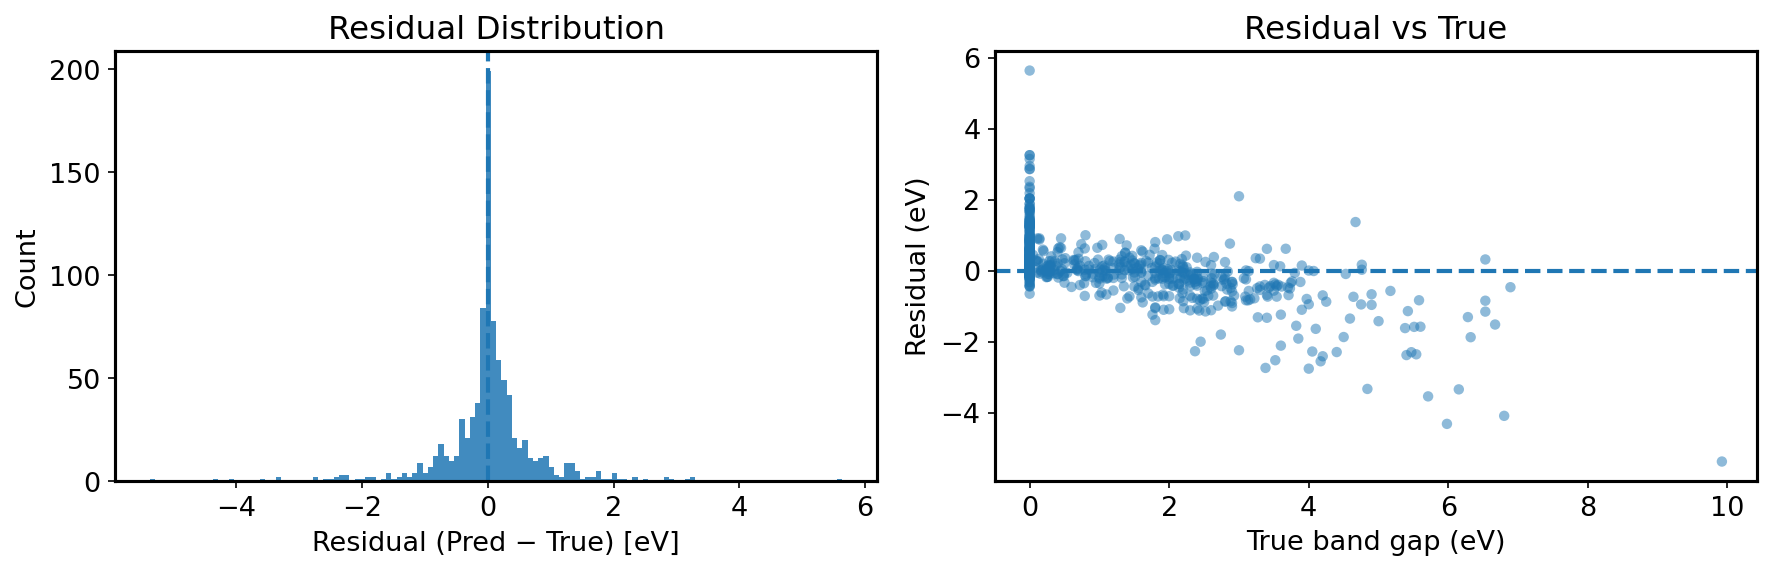

In [28]:


best_pred = pred_store[best_model_name]
residuals = best_pred - y_test

plt.rcParams.update({
    "font.size": 13,
    "axes.linewidth": 1.5,
    "figure.dpi": 150
})

fig, ax = plt.subplots(1, 2, figsize=(12,4))

# ===== Residual histogram =====
ax[0].hist(residuals, bins="auto", alpha=0.85)
ax[0].axvline(0, linestyle="--", linewidth=2)
ax[0].set_xlabel("Residual (Pred − True) [eV]")
ax[0].set_ylabel("Count")
ax[0].set_title("Residual Distribution")

# ===== Residual vs actual =====
ax[1].scatter(
    y_test, residuals,
    alpha=0.5,
    s=25,
    edgecolors="none"
)

ax[1].axhline(0, linestyle="--", linewidth=2)
ax[1].set_xlabel("True band gap (eV)")
ax[1].set_ylabel("Residual (eV)")
ax[1].set_title("Residual vs True")

plt.tight_layout()
plt.show()

The figure compares the prediction errors (MAE) of the models developed in this work with several reference models reported on the MatBench benchmark. Each point represents the mean MAE, and the error bars indicate the standard deviation from cross-validation. Grey points correspond to benchmark models from the MatBench leaderboard, blue points represent the models trained in this study, and the red point highlights the best-performing model in my study(tuned XGBoost). The broken y-axis is used to improve visual clarity by separating the much larger error of the dummy baseline from the other models.


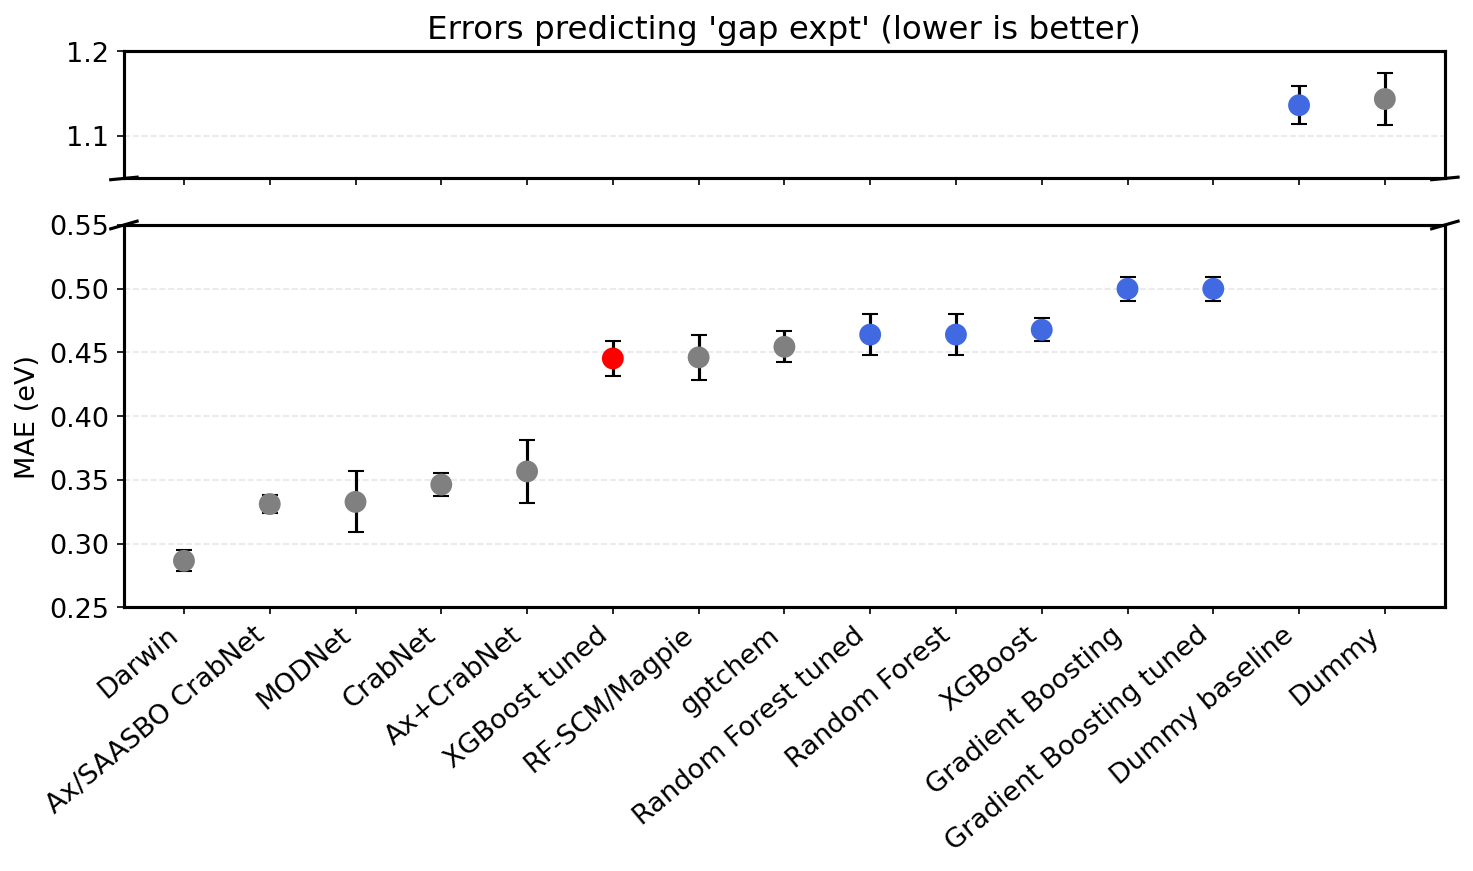

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===== Your models =====
your_mae = cv_df.set_index("model")["cv_mae_mean"]
your_std = cv_df.set_index("model")["cv_mae_std"]

your_mae.index = your_mae.index.str.replace("Dummy (mean)", "Dummy baseline")
your_std.index = your_std.index.str.replace("Dummy (mean)", "Dummy baseline")

# ===== Benchmark models =====
benchmark_mae = pd.Series({
    "Darwin": 0.2865,
    "Ax/SAASBO CrabNet": 0.3310,
    "MODNet": 0.3327,
    "CrabNet": 0.3463,
    "Ax+CrabNet": 0.3566,
    "RF-SCM/Magpie": 0.4461,
    "gptchem": 0.4544,
    "Dummy": 1.1435
})

benchmark_std = pd.Series({
    "Darwin": 0.0083,
    "Ax/SAASBO CrabNet": 0.0071,
    "MODNet": 0.0239,
    "CrabNet": 0.0088,
    "Ax+CrabNet": 0.0248,
    "RF-SCM/Magpie": 0.0177,
    "gptchem": 0.0123,
    "Dummy": 0.031
})

# ===== Combine =====
all_mae = pd.concat([benchmark_mae, your_mae])
all_std = pd.concat([benchmark_std, your_std])

order = all_mae.sort_values().index
all_mae = all_mae.loc[order]
all_std = all_std.loc[order]

# ===== Colors =====
colors = []
for name in all_mae.index:

    if name == "XGBoost tuned":
        colors.append("red")

    elif name in your_mae.index:
        colors.append("royalblue")

    else:
        colors.append("gray")

# ===== Broken axis plot =====
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, sharex=True,
    figsize=(10,6),
    gridspec_kw={"height_ratios":[1,3]}
)

# ----- TOP (dummy region) -----
ax_top.errorbar(
    all_mae.index,
    all_mae.values,
    yerr=all_std.values,
    fmt='o',
    color='black',
    capsize=4
)

ax_top.scatter(
    all_mae.index,
    all_mae.values,
    c=colors,
    s=90,
    zorder=3
)

ax_top.set_ylim(1.05, 1.2)

# ----- BOTTOM (main models) -----
ax_bottom.errorbar(
    all_mae.index,
    all_mae.values,
    yerr=all_std.values,
    fmt='o',
    color='black',
    capsize=4
)

ax_bottom.scatter(
    all_mae.index,
    all_mae.values,
    c=colors,
    s=90,
    zorder=3
)

ax_bottom.set_ylim(0.25, 0.55)

# ----- aesthetics -----
ax_bottom.set_ylabel("MAE (eV)")
ax_top.set_title("Errors predicting 'gap expt' (lower is better)")

ax_bottom.grid(axis="y", linestyle="--", alpha=0.3)
ax_top.grid(axis="y", linestyle="--", alpha=0.3)

plt.xticks(rotation=40, ha="right")

# diagonal break marks
d = .01
kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False)

ax_top.plot((-d,+d),(-d,+d), **kwargs)
ax_top.plot((1-d,1+d),(-d,+d), **kwargs)

kwargs.update(transform=ax_bottom.transAxes)

ax_bottom.plot((-d,+d),(1-d,1+d), **kwargs)
ax_bottom.plot((1-d,1+d),(1-d,1+d), **kwargs)

plt.tight_layout()
plt.show()

## Large Language Model (LLM) usage declaration

Acknowledge use of a generative model during your assignment. Points to consider:

* State which LLM (e.g. GPT-4, Gemini, Co-Pilot)

* Specify tasks (e.g. summarising research or code snippets)

* Were any limitations/biases noted?

* How did you ensure ethical use?

ChatGPT (GPT-5.2) was used for limited assistance with Python debugging and improving the clarity of written explanations. All analysis, model training, and evaluation were carried out independently, and all generated suggestions were reviewed and verified before use.

## ☘️ Final word

Good luck building your own model! We hope that you enjoyed the course and exercises. Dive deeper into the aspects that caught your interest. A useful starting point may be the [Resources](https://aronwalsh.github.io/MLforMaterials/Resources.html) page.

Remember that submission is on Blackboard and you should upload both the completed Juypter Notebook (`.ipynb` file), as well as your recorded narrated presentation (maximum 5 minutes; see guides on using [Zoom](https://www.youtube.com/watch?v=H9qhoAIzW3E) or [Powerpoint](https://www.youtube.com/watch?v=Y5dgwwa5XRA) for this purpose).